# Kalman Filter Benchmark

Classical estimation baseline for the Gibson–Schwartz (GS) Model 2 two-factor
model, fit on the real WTI futures panel (`data/input/real/wti_analysis_ready.csv`).
This is the benchmark the PINN's $\delta_t$ inversion (`AP-PEN.ipynb`)
is judged against.

Based on Krul, A. (2008), *Calibration of Stochastic Convenience Yield Models
for Crude Oil Using the Kalman Filter* (MSc thesis, TU Delft / ING Wholesale
Banking), Chapter 4 — the reference for turning the GS closed-form futures
price into a Kalman-filter estimator. We keep its design:

- **Joint state** $(x_t, \delta_t)$, $x_t=\ln S_t$ — both log-spot and
  convenience yield are latent, inferred jointly from the futures curve alone
  (Krul eq. 4.2). We use the real observed spot only to initialize $x_0$.
- **Euler-Maruyama transition** (Krul eq. 4.5-4.7) — also this project's own
  simulator convention.
- **Market-implied $\delta_0$ initialization** (Krul eq. 4.9), and $\lambda$
  (market price of risk) estimated directly so $\alpha^{\mathbb Q}=
  \alpha^{\mathbb P}-\sigma_2\lambda/\kappa$ falls out as a
  constraint rather than two independently free parameters.
- **MLE via the prediction-error decomposition log-likelihood** (Krul eq.
  4.8), using `jax.grad` + L-BFGS-B in place of the thesis's numerical-gradient
  Matlab `fmincon`.

We use the *actual* per-date trading gap $dt_t$ and observed daily rate $r_t$
(irregular, real data) rather than Krul's fixed weekly step, since our
dataset is daily and shares its loader with `AP-PEN.ipynb`.

Self-contained: the closed-form GS pricer is copied in below (not imported from
`gs_wamol`), matching the convention already used in `AP-PEN.ipynb`.


In [1]:
import time
import json
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import jax
# float64: the KF recursion inverts a small covariance matrix at every one of
# ~2700 daily steps, and float32 errors (~1e-5 floor) compound
# over a long recursion.
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax

np.set_printoptions(precision=4, suppress=True)
print("JAX:", jax.__version__, "| x64 enabled:", jax.config.jax_enable_x64)


JAX: 0.9.1 | x64 enabled: True


### Closed-form Gibson–Schwartz pricer

$$\hat F(\tau, S, \delta) = S\exp\!\big[B(\tau)\delta + A(\tau)\big], \qquad
B(\tau) = -\frac{1-e^{-\kappa\tau}}{\kappa}$$

Copied in from `src/gs_wamol/physics/gibson_schwartz.py` —
do not edit these coefficients without re-checking the PDE residual in float64.
Written as plain functions of scalars (not the `GSParams` dataclass) so
`jax.grad` can differentiate the log-likelihood through them during MLE.


In [2]:
def B_coeff(tau, kappa):
    """B(tau) = -(1 - e^{-kappa tau}) / kappa. Loading on delta in log F_hat."""
    return -(1.0 - jnp.exp(-kappa * tau)) / kappa


def A_coeff(tau, r, kappa, alpha_Q, sigma1, sigma2, rho):
    """A(tau): the delta-independent part of log F_hat. Takes r (risk-free rate)
    as an explicit argument rather than baking it into a params object, since we
    use the REAL observed daily rate column (data-driven r_t), not a fixed constant.
    """
    s1s2rho = sigma1 * sigma2 * rho
    s2sq = sigma2 ** 2

    lin = (r - alpha_Q + 0.5 * s2sq / kappa ** 2 - s1s2rho / kappa) * tau
    two_kappa = 0.25 * s2sq * (1.0 - jnp.exp(-2.0 * kappa * tau)) / kappa ** 3
    one_kappa = (alpha_Q * kappa + s1s2rho - s2sq / kappa) * (1.0 - jnp.exp(-kappa * tau)) / kappa ** 2
    return lin + two_kappa + one_kappa


### Load the real WTI panel

Same long-to-rectangular reshape as `get_data_wti` in `AP-PEN.ipynb`:
each date's live contracts are ranked by $\tau$ into fixed maturity "slots"
0..7 (8 = the modal contract count; dates with fewer are dropped, ~96% kept).
`taus` is fixed at each slot's mean $\tau$ — a static stand-in for the true
per-date shrinking $\tau$.

It also builds the Krul-style initialization values (his sec. 4.2.1):
$\delta_0$ from the two nearest maturities at $t=0$ (eq. 4.9, a model-free
basis estimate of cost-of-carry), $x_0=\ln S_0$ from the real observed spot
(Krul used a futures-price proxy; we have better data for the same role), and
`h0_guess` from the per-maturity variance of the observed log futures price.

The real observed daily rate `r_t` and actual calendar gap `dt_t` (trading
days aren't evenly spaced — weekends, holidays, and dropped low-liquidity
dates show up as 1-8 day gaps) are used directly, not approximated.


In [3]:
_WTI_DATA_PATH = "../data/input/real/wti_analysis_ready.csv"


def load_wti_panel(path=_WTI_DATA_PATH, n_maturities=8):
    """Long (date x contract) panel -> rectangular (dates x n_maturities) arrays,
    plus the Krul-style values used to initialize the filter (see markdown above).
    """
    df = pd.read_csv(path)
    df = df.dropna(subset=["spot", "rate"])  # drops 2020-04-20 (negative-price day)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["date", "tau"])
    df["slot"] = df.groupby("date").cumcount()
    df = df[df["slot"] < n_maturities]
    df = df[df.groupby("date")["slot"].transform("count") == n_maturities]

    tau_matrix = df.pivot(index="date", columns="slot", values="tau").sort_index()
    settle_matrix = df.pivot(index="date", columns="slot", values="settle").sort_index()
    spot_by_date = df.groupby("date")["spot"].first().sort_index()
    rate_by_date = df.groupby("date")["rate"].first().sort_index()

    dates = tau_matrix.index.to_numpy()
    dt = np.diff(dates).astype("timedelta64[D]").astype(float) / 365.0    # (T-1,)
    taus = tau_matrix.to_numpy().mean(axis=0)                             # (K,)
    logF_obs = np.log(settle_matrix.to_numpy())                           # (T, K)
    r = rate_by_date.to_numpy()                                           # (T,)
    spot = spot_by_date.to_numpy()                                        # (T,)

    # Krul eq. 4.9: model-free basis estimate of delta_0 from the two nearest maturities.
    tau1, tau2 = taus[0], taus[1]
    lnF1, lnF2 = logF_obs[0, 0], logF_obs[0, 1]
    delta0_guess = (r[0] * tau1 - r[0] * tau2) / (tau1 - tau2) - (lnF1 - lnF2) / (tau1 - tau2)

    h0_guess = logF_obs.var(axis=0)                                       # (K,)
    r_t = r[1:]  # t=0 has no preceding state to transition FROM, so it's prior-only

    return dates, dt, taus, logF_obs, r_t, spot, delta0_guess, h0_guess


dates, dt, taus, logF_obs, r_t, spot, delta0_guess, h0_guess = load_wti_panel()
logS0 = float(np.log(spot[0]))
K = taus.shape[0]

print("dates       ", dates.shape, dates[0], "->", dates[-1])
print("dt          ", dt.shape, f"[{dt.min():.4f}, {dt.max():.4f}] yrs  (mean {dt.mean():.4f})")
print("taus        ", taus.shape, np.round(taus, 3))
print("logF_obs    ", logF_obs.shape, "(dates x maturities), the KF's measurement vector")
print("logS0       ", f"{logS0:.4f}", f"(S0 = ${np.exp(logS0):.2f})")
print("delta0_guess", f"{delta0_guess:+.4f}", "(Krul eq. 4.9)")


dates        (2770,) 2015-01-02T00:00:00.000000 -> 2026-02-19T00:00:00.000000
dt           (2769,) [0.0027, 0.0219] yrs  (mean 0.0040)
taus         (8,) [0.125 0.375 0.625 0.875 1.125 1.376 1.626 1.876]
logF_obs     (2770, 8) (dates x maturities), the KF's measurement vector
logS0        3.9644 (S0 = $52.69)
delta0_guess -0.1505 (Krul eq. 4.9)


### State-space model (Krul sec. 4.1)

**State:** $\alpha_t=(x_t,\delta_t)$, $x_t=\ln S_t$. Both latent, inferred
purely from the futures curve.

**Transition (ℙ measure — measure discipline: ℙ simulates,
ℚ prices), Euler-Maruyama over the true calendar step $dt_t$** (Krul eq. 4.5-4.7):
$$
\begin{pmatrix}x_t\\ \delta_t\end{pmatrix} =
\underbrace{\begin{pmatrix}(\mu-\tfrac12\sigma_1^2)dt_t\\ \kappa\alpha^{\mathbb P}dt_t\end{pmatrix}}_{c_t}
+ \underbrace{\begin{pmatrix}1 & -dt_t\\ 0 & 1-\kappa\, dt_t\end{pmatrix}}_{Q_t}
\begin{pmatrix}x_{t-1}\\ \delta_{t-1}\end{pmatrix} + \xi_t,
\qquad \xi_t\sim\mathcal N\!\Big(0,\ dt_t\begin{pmatrix}\sigma_1^2 & \rho\sigma_1\sigma_2\\ \rho\sigma_1\sigma_2 & \sigma_2^2\end{pmatrix}\Big)
$$

**Measurement (ℚ measure — exact affine GS closed form)** (Krul eq. 4.2-4.3):
$$y_t = \underbrace{\big[A(\tau_j)\big]_j}_{d_t} + \underbrace{\begin{pmatrix}1 & B(\tau_1)\\ \vdots & \vdots\\ 1 & B(\tau_K)\end{pmatrix}}_{Z}\begin{pmatrix}x_t\\ \delta_t\end{pmatrix} + v_t,\qquad v_t\sim\mathcal N(0, \mathrm{diag}(h_1,\dots,h_K))$$
$Z$ is exactly linear in $(x_t,\delta_t)$ — why a plain linear KF is exact
here, no Extended/Unscented KF needed. One noise variance $h_j$ per maturity
(Krul), since near- and far-dated contracts trade with different liquidity.

$\alpha^{\mathbb Q}$ is computed each iteration from $\alpha^{\mathbb P} -
\sigma_2\lambda/\kappa$, not fit directly.

#### Concept breakdown: Kalman filter
**What it is:** a recursive Bayesian estimator that alternates *predict*
(propagate the state through the transition model) and *update* (correct that
prediction with a new noisy observation, weighted by relative uncertainty).
**Intuition:** a running weighted average between "what the model expects"
and "what the market just told us" — the Kalman gain shifts weight toward the
data when the model is uncertain, toward the model when the data is noisy.
**Common gotcha:** it's easy to silently mix up which parameters belong to ℙ
vs ℚ; the filter still runs, it just estimates something that isn't the model
you think it is.


In [4]:
# Move data onto device once, as JAX arrays -- avoids re-transferring inside the
# jit-compiled loss on every optimizer iteration.
taus_j = jnp.asarray(taus)
logF_obs_j = jnp.asarray(logF_obs[1:])   # (T-1, K) -- t=0 has no preceding state to score
r_t_j = jnp.asarray(r_t)
dt_j = jnp.asarray(dt)
N_PARAMS = 7 + K   # kappa, mu, alpha_P, lambda, sigma1, sigma2, rho, h_1..h_K


def unpack_psi(raw):
    """Unconstrained (raw, length 7+K) -> constrained model parameters.

    softplus maps R -> (0, inf) for kappa/sigma1/sigma2/h_j; tanh maps R ->
    (-1, 1) for rho. Same "unconstrained optimizer + reparameterize" trick
    build_nets/constrain_psi uses in AP-PEN.ipynb, in place of
    Krul's explicit box constraints passed to fmincon -- gives exact
    gradients through the constraint via autodiff.
    """
    return dict(
        kappa=jax.nn.softplus(raw[0]) + 1e-4,
        mu=raw[1],
        alpha_P=raw[2],
        lam=raw[3],
        sigma1=jax.nn.softplus(raw[4]) + 1e-4,
        sigma2=jax.nn.softplus(raw[5]) + 1e-4,
        rho=jnp.tanh(raw[6]),
        h=jax.nn.softplus(raw[7:7 + K]) + 1e-8,
    )


def run_filter(raw):
    """One full forward pass of the joint (x_t, delta_t) Kalman filter at a
    given raw-psi (Krul sec. 4.1, algorithm in his Appendix A.1).
    """
    psi = unpack_psi(raw)
    kappa, mu, alpha_P, lam = psi["kappa"], psi["mu"], psi["alpha_P"], psi["lam"]
    sigma1, sigma2, rho, h = psi["sigma1"], psi["sigma2"], psi["rho"], psi["h"]
    alpha_Q = alpha_P - sigma2 * lam / kappa    # P -> Q measure-change relation

    Z = jnp.stack([jnp.ones(K), B_coeff(taus_j, kappa)], axis=1)   # (K, 2) measurement matrix
    R = jnp.diag(h)                                                # (K, K) per-maturity noise

    a0 = jnp.array([logS0, delta0_guess])            # Krul-style initial state (sec. 4.2.1)
    P0 = jnp.diag(jnp.array([0.05 ** 2, 0.1 ** 2]))   # modest diffuse prior; KF is insensitive to this

    def step(carry, xs):
        a_prev, P_prev, loglik = carry        # a_prev: (2,); P_prev: (2,2); loglik: scalar
        dt_t, y_t, r_val = xs                 # dt_t: scalar; y_t: (K,); r_val: scalar

        # --- predict (Euler-Maruyama transition) ---
        Q_t = jnp.array([[1.0, -dt_t],
                          [0.0, 1.0 - kappa * dt_t]])
        c_t = jnp.array([(mu - 0.5 * sigma1 ** 2) * dt_t, kappa * alpha_P * dt_t])
        V_t = dt_t * jnp.array([[sigma1 ** 2, rho * sigma1 * sigma2],
                                 [rho * sigma1 * sigma2, sigma2 ** 2]])
        a_pred = c_t + Q_t @ a_prev
        P_pred = Q_t @ P_prev @ Q_t.T + V_t

        # --- update (exact affine GS measurement) ---
        d_t = A_coeff(taus_j, r_val, kappa, alpha_Q, sigma1, sigma2, rho)   # (K,) ℚ-measure intercept
        innov = y_t - (d_t + Z @ a_pred)                                    # (K,) prediction error
        S_t = Z @ P_pred @ Z.T + R                                          # (K, K) innovation covariance
        S_inv = jnp.linalg.inv(S_t)
        gain = P_pred @ Z.T @ S_inv                                         # (2, K) Kalman gain
        a_new = a_pred + gain @ innov
        P_new = P_pred - gain @ Z @ P_pred

        # Prediction-error decomposition of the Gaussian log-likelihood (Krul eq. 4.8) --
        # this IS the log-lik of the observed data under the model, exactly.
        _, logdet_S = jnp.linalg.slogdet(S_t)
        ll_t = -0.5 * (K * jnp.log(2 * jnp.pi) + logdet_S + innov @ S_inv @ innov)

        return (a_new, P_new, loglik + ll_t), (a_new, P_new, innov)

    init_carry = (a0, P0, 0.0)
    (_, _, total_loglik), (a_path, P_path, innovs) = lax.scan(
        step, init_carry, (dt_j, logF_obs_j, r_t_j)
    )
    return total_loglik, a_path, P_path, innovs


def neg_log_lik(raw):
    total_loglik, _, _, _ = run_filter(raw)
    return -total_loglik


# jit once; jax.grad gives the EXACT gradient of the likelihood through the whole
# scan (autodiff, not finite differences) -- this is what makes MLE over a ~2700
# step recursive filter converge in seconds instead of minutes.
nll_and_grad = jax.jit(jax.value_and_grad(neg_log_lik))


### Fit by maximum likelihood (Krul sec. 4.1.1 / 4.2.1)

#### Concept breakdown: MLE via prediction-error decomposition
**What it is:** choosing $\hat\psi=\arg\max_\psi\sum_t\ln p(y_t\mid
y_{1:t-1};\psi)$. For a linear-Gaussian state-space model each term is
exactly the filter's own innovation Gaussian $\mathcal N(0,S_t)$ — no extra
approximation from using the KF to build the likelihood.
**Common gotcha:** the likelihood surface for mean-reverting processes is
often flat along a $\kappa$-vs-$\lambda$ ridge (the
"$\kappa$-$\lambda$ entanglement"; Krul notes the same in his sec.7.1) — the
filtered $\hat\delta_t$ path is generally much better identified than any
single parameter, so don't over-read precision into $\hat\kappa$/$\hat\lambda$
individually.

We initialize $(\kappa,\mu,\alpha^{\mathbb P},\sigma_1,\sigma_2,\rho)$ from
`config/p_params.json` and $\lambda$ from `config/q_params.json`'s
`lambda2` — plausible literature-scale GS values, not a real-data fit.
$\delta_0$ and each $h_j$ start from the data-driven guesses built above.


In [5]:
def inv_softplus(y):
    return np.log(np.expm1(np.asarray(y, dtype=np.float64)))


def inv_tanh(y):
    return float(np.arctanh(y))


with open("../config/p_params.json") as f:
    p0 = json.load(f)
with open("../config/q_params.json") as f:
    q0 = json.load(f)

raw0 = np.concatenate([
    np.array([
        inv_softplus(p0["kappa"]), p0["mu"], p0["alpha_P"], q0["lambda2"],
        inv_softplus(p0["sigma1"]), inv_softplus(p0["sigma2"]),
        inv_tanh(np.clip(p0["rho"], -0.999, 0.999)),
    ]),
    inv_softplus(np.maximum(h0_guess, 1e-4)),
])
assert raw0.shape == (N_PARAMS,)


def scipy_objective(raw_np):
    # scipy wants (value, gradient) as plain numpy float64 -- jax gives us both
    # in one pass via value_and_grad, we just convert dtypes at the boundary.
    value, grad = nll_and_grad(jnp.asarray(raw_np))
    return float(value), np.asarray(grad, dtype=np.float64)


t0 = time.time()
res = minimize(scipy_objective, raw0, jac=True, method="L-BFGS-B",
                options=dict(maxiter=500))
fit_seconds = time.time() - t0

raw_star = jnp.asarray(res.x)
psi_hat = {k: (float(v) if v.ndim == 0 else np.asarray(v))
           for k, v in unpack_psi(raw_star).items()}
psi_hat["alpha_Q"] = psi_hat["alpha_P"] - psi_hat["sigma2"] * psi_hat["lam"] / psi_hat["kappa"]

print(f"converged: {res.success}  |  iterations: {res.nit}  |  fit time: {fit_seconds:.2f}s")
print(f"log-likelihood at optimum: {-res.fun:.2f}\n")
print("estimated psi:")
for k, v in psi_hat.items():
    if k == "h":
        print(f"  {k:10s} = {np.round(v, 5)}  (per-maturity measurement-noise variance)")
    else:
        print(f"  {k:10s} = {v:+.4f}")


converged: True  |  iterations: 313  |  fit time: 38.76s
log-likelihood at optimum: 84707.52

estimated psi:
  kappa      = +0.4257
  mu         = +0.1576
  alpha_P    = +0.1007
  lam        = +0.4390
  sigma1     = +0.4397
  sigma2     = +0.1726
  rho        = +0.8883
  h          = [0.0022 0.0002 0.     0.     0.     0.     0.     0.    ]  (per-maturity measurement-noise variance)
  alpha_Q    = -0.0773


### Recover the filtered $(\hat x_t, \hat\delta_t)$ path

Re-run the filter at $\hat\psi$ (`raw_star`) to pull out the per-date filtered
mean/variance and innovations: $\hat\delta_t$ is the convenience-yield
estimate this baseline produces (what the PINN's $\hat\delta_\phi(t)$ gets
compared against), and $\exp(\hat x_t)$ is the model's own log-spot inferred
purely from the futures curve — plotted against the real observed spot as a
sanity check that a large systematic gap there would flag a problem with the
model, not just be a curiosity.


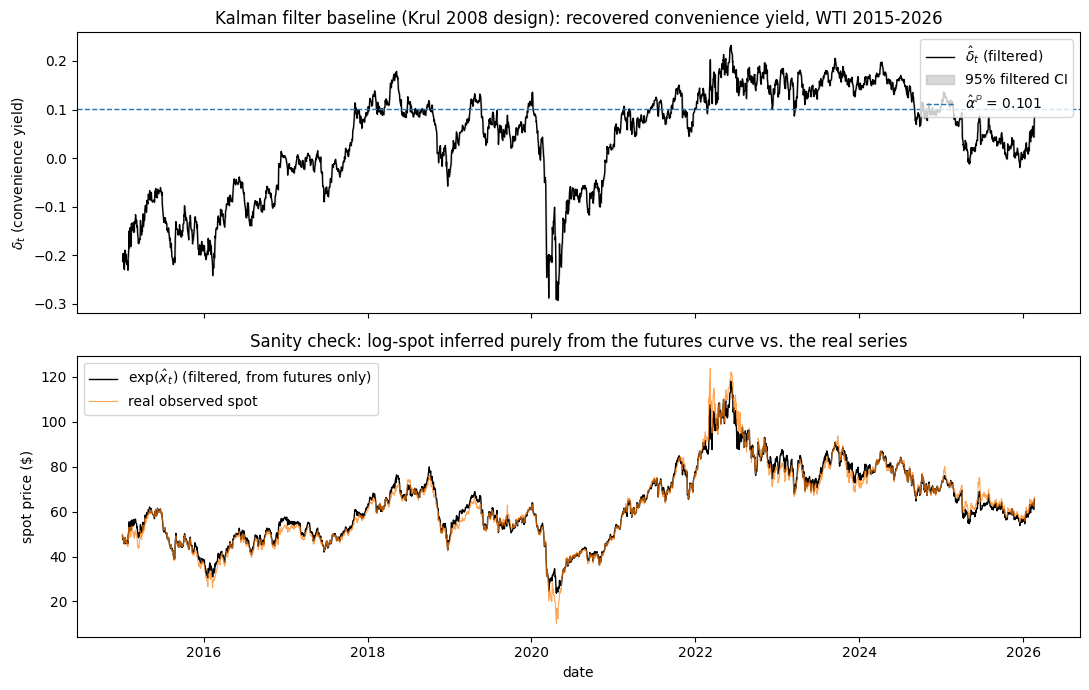

delta_hat: mean=+0.0395  std=0.1078  range=[-0.2925, +0.2320]
in-sample innovation RMSE (log-price): 0.0263  (~2.6% typical daily futures-price misfit)
filtered exp(x_t) vs real spot, RMSE: 6.88%  (inferred purely from the futures curve, never observing spot directly)


In [6]:
_, a_path, P_path, innovs = run_filter(raw_star)
a_path = np.asarray(a_path)     # (T-1, 2) filtered [x_t, delta_t], one row per date after the first
P_path = np.asarray(P_path)     # (T-1, 2, 2) filtered covariance
innovs = np.asarray(innovs)     # (T-1, K) prediction errors, one row per date
dates_filtered = dates[1:]      # align dates to a_path (t=0 has no filtered estimate, only a prior)

x_path, delta_path = a_path[:, 0], a_path[:, 1]
delta_var = P_path[:, 1, 1]
band = 1.96 * np.sqrt(delta_var)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(dates_filtered, delta_path, color="black", lw=1, label=r"$\hat\delta_t$ (filtered)")
ax1.fill_between(dates_filtered, delta_path - band, delta_path + band,
                  color="gray", alpha=0.3, label="95% filtered CI")
ax1.axhline(psi_hat["alpha_P"], color="tab:blue", lw=1, ls="--",
            label=fr"$\hat\alpha^{{\mathbb{{P}}}}$ = {psi_hat['alpha_P']:.3f}")
ax1.set_ylabel(r"$\delta_t$ (convenience yield)")
ax1.set_title("Kalman filter baseline (Krul 2008 design): recovered convenience yield, WTI 2015-2026")
ax1.legend(loc="upper right")

ax2.plot(dates_filtered, np.exp(x_path), color="black", lw=1, label=r"$\exp(\hat x_t)$ (filtered, from futures only)")
ax2.plot(dates_filtered, spot[1:], color="tab:orange", lw=0.8, alpha=0.7, label="real observed spot")
ax2.set_ylabel("spot price ($)")
ax2.set_xlabel("date")
ax2.set_title("Sanity check: log-spot inferred purely from the futures curve vs. the real series")
ax2.legend(loc="upper left")

fig.tight_layout()
plt.show()

rmse_logprice = np.sqrt((innovs ** 2).mean())
rmse_spot_pct = np.sqrt(np.mean((np.exp(x_path) / spot[1:] - 1.0) ** 2)) * 100
print(f"delta_hat: mean={delta_path.mean():+.4f}  std={delta_path.std():.4f}  "
      f"range=[{delta_path.min():+.4f}, {delta_path.max():+.4f}]")
print(f"in-sample innovation RMSE (log-price): {rmse_logprice:.4f}  "
      f"(~{100*rmse_logprice:.1f}% typical daily futures-price misfit)")
print(f"filtered exp(x_t) vs real spot, RMSE: {rmse_spot_pct:.2f}%  "
      f"(inferred purely from the futures curve, never observing spot directly)")


### Sanity check: fitted vs observed term structure on one date

A $\hat\delta_t$ time series alone can't show whether the *curve shape* fits
well at any single date — plot one date's actual futures curve against the
model's fitted curve at $\hat\psi,\hat\delta_t$.


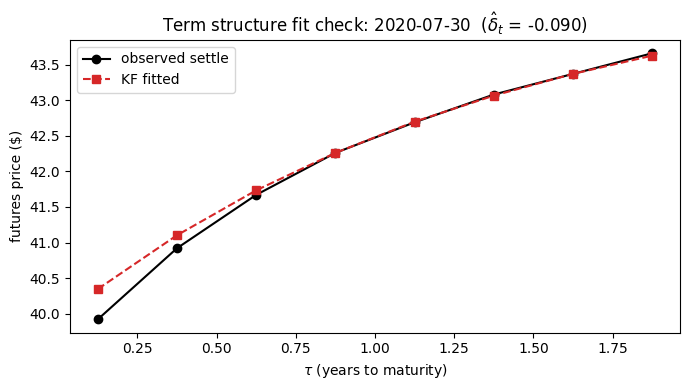

In [7]:
# a_path/innovs/r_t are all aligned by the same index (t=0 already dropped);
# pick a date roughly in the middle of the sample as a representative check.
check_idx = len(dates_filtered) // 2
check_date = dates_filtered[check_idx]

logF_obs_curve = logF_obs[check_idx + 1]     # +1: logF_obs still has the t=0 row, a_path doesn't
A_hat = np.asarray(A_coeff(taus_j, r_t[check_idx], psi_hat["kappa"], psi_hat["alpha_Q"],
                            psi_hat["sigma1"], psi_hat["sigma2"], psi_hat["rho"]))
B_hat = np.asarray(B_coeff(taus_j, psi_hat["kappa"]))
logF_fitted_curve = x_path[check_idx] + B_hat * delta_path[check_idx] + A_hat

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(taus, np.exp(logF_obs_curve), "o-", color="black", label="observed settle")
ax.plot(taus, np.exp(logF_fitted_curve), "s--", color="tab:red", label="KF fitted")
ax.set_xlabel(r"$\tau$ (years to maturity)")
ax.set_ylabel("futures price ($)")
ax.set_title(f"Term structure fit check: {pd.Timestamp(check_date).date()}  "
             fr"($\hat\delta_t$ = {delta_path[check_idx]:+.3f})")
ax.legend()
fig.tight_layout()
plt.show()


### Save results

`data/output/` is gitignored and regenerable (see the README's on-disk
layout) — re-run this notebook to regenerate this pickle.


In [ ]:
os.makedirs("../data/output/kalman/results", exist_ok=True)

results_kalman = {
    "dates": dates_filtered,          # (T-1,) datetime64
    "x_hat": x_path,                  # (T-1,) filtered log-spot (inferred, not observed)
    "delta_hat": delta_path,          # (T-1,) filtered convenience-yield estimate
    "delta_var": delta_var,           # (T-1,) filtered variance of delta_t
    "innovations": innovs,            # (T-1, K) prediction errors
    "psi_hat": psi_hat,               # {kappa, mu, alpha_P, lam, sigma1, sigma2, rho, h, alpha_Q}
    "taus": taus,                     # (K,) maturity slots used
    "loglik": float(-res.fun),
    "converged": bool(res.success),
    "reference": "Krul (2008), Calibration of Stochastic Convenience Yield Models "
                 "for Crude Oil Using the Kalman Filter, MSc thesis, TU Delft, ch.4",
}

with open("../data/output/kalman/results/results_kalman.pkl", "wb") as f:
    pickle.dump(results_kalman, f)

print("saved ../data/output/kalman/results/results_kalman.pkl")


### Known limitations (flagging, not fixing here — keep this notebook simple)

- **$\kappa$-$\lambda$ entanglement**: don't over-interpret point precision on
  $\kappa$, $\alpha^{\mathbb P}$, $\lambda$ individually (see
  Krul's sec.7.1). The filtered $\hat\delta_t$ path is generally much better
  identified than any single parameter.
- **Euler-Maruyama transition, not exact OU**: matches Krul's own
  discretization and this project's synthetic-data simulator, at the cost of
  a small bias on the handful of steps with the largest calendar gaps.
- **No delta floor / no-arbitrage constraint**: unlike the PINN's `e_cac`/`e_rcac`
  hinge terms, this KF has no floor or ceiling on $\hat\delta_t$ — extreme
  values are mathematically fine even if economically unusual. Krul hits the
  same issue and moves to a CIR (non-negative) process in his Chapter 5, at
  the cost of losing the exact-linear-KF property.
- **Fixed mean $\tau$ per maturity slot**, not the true per-date shrinking
  $\tau$ — same simplification `get_data_wti` uses in `AP-PEN.ipynb`,
  so the two baselines stay comparable.
- **One MLE run from one initial guess**: L-BFGS-B's "converged" flag means it
  stopped improving, not that this is the global optimum — worth a multi-start
  check (as Krul does, his Table 4.1) before treating $\hat\psi$ as final.

**Reference:** Krul, A. (2008). *Calibration of Stochastic Convenience Yield
Models for Crude Oil Using the Kalman Filter.* MSc thesis, Delft University of
Technology / ING Wholesale Banking.
